In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import torch

data_path = "ETH_analysis_results/final_analysis_eth_test_set/model__devicecpu100_6_100_100_1001_100_2_50_encoderislearnable_lambda0.5_alpha1.0_bs128_bnisFalse_lr0.0001_pene0/trained_for_60_epochs_/period_1850_2100/data/"


In [2]:
cq_fact_memb0 = np.load(f"{data_path}/cq_spatial_test_member0_factual_01-99.npy")
cq_fact_memb1 = np.load(f"{data_path}/cq_spatial_test_member1_factual_01-99.npy")
cq_fact_memb2 = np.load(f"{data_path}/cq_spatial_test_member2_factual_01-99.npy")

cq_cf_memb0 = np.load(f"{data_path}/cq_spatial_test_member0_counterfactual_01-99.npy")
cq_cf_memb1 = np.load(f"{data_path}/cq_spatial_test_member1_counterfactual_01-99.npy")
cq_cf_memb2 = np.load(f"{data_path}/cq_spatial_test_member2_counterfactual_01-99.npy")

cq_fact_memb1.shape
# load mae
mae_fact = torch.load(f"{data_path}/all_mae_fact.pt")
mae_cf = torch.load(f"{data_path}/all_mae_cf.pt")

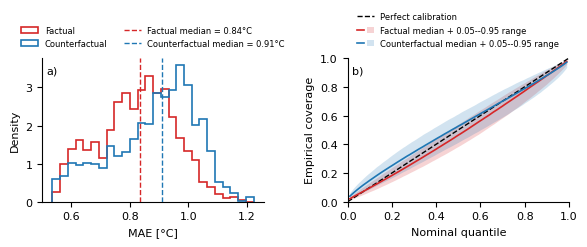

In [3]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple

# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------

FIG_WIDTH_MM = 153
FIG_WIDTH_IN = FIG_WIDTH_MM / 25.4
FIG_HEIGHT_IN = FIG_WIDTH_IN * 0.42

FONT_SIZE = 8

plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE - 1,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ---------------------------------------------------------------------
# Convert MAE tensors to NumPy
# ---------------------------------------------------------------------

mae_fact_np = mae_fact.detach().cpu().numpy().ravel()
mae_cf_np = mae_cf.detach().cpu().numpy().ravel()

all_mae = np.concatenate([mae_fact_np, mae_cf_np])
all_mae = all_mae[~np.isnan(all_mae)]

# ---------------------------------------------------------------------
# Prepare calibration data
# ---------------------------------------------------------------------

cq_fact = np.concatenate(
    [cq_fact_memb0, cq_fact_memb1, cq_fact_memb2],
    axis=0,
)

cq_cf = np.concatenate(
    [cq_cf_memb0, cq_cf_memb1, cq_cf_memb2],
    axis=0,
)

quantiles = np.linspace(0.01, 0.99, 99)

fact_quantiles = np.quantile(cq_fact, quantiles, axis=0)
cf_quantiles = np.quantile(cq_cf, quantiles, axis=0)

# ---------------------------------------------------------------------
# Compute MAE medians
# ---------------------------------------------------------------------

median_fact = np.median(mae_fact_np)
median_cf = np.nanmedian(mae_cf_np)

# ---------------------------------------------------------------------
# Figure
# ---------------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN),
)

# ---------------------------------------------------------------------
# Panel A: MAE histograms
# ---------------------------------------------------------------------

bins = np.histogram_bin_edges(all_mae, bins="auto")

axes[0].hist(
    mae_fact_np,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=1.2,
    label="Factual",
    color="tab:red"
)

axes[0].hist(
    mae_cf_np,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=1.2,
    label="Counterfactual",
    color="tab:blue"
)

# Add vertical lines for medians
axes[0].axvline(
    median_fact,
    color="tab:red",
    linestyle="--",
    linewidth=1.0,
    label=f"Factual median = {median_fact:.2f}°C",
    zorder=10
)

axes[0].axvline(
    median_cf,
    color="tab:blue",
    linestyle="--",
    linewidth=1.0,
    label=f"Counterfactual median = {median_cf:.2f}°C",
    zorder=10
)

axes[0].set_xlabel("MAE [°C]")
axes[0].set_ylabel("Density")

# Move legend above the histogram
axes[0].legend(
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    fontsize=FONT_SIZE - 2
)

# ---------------------------------------------------------------------
# Panel B: spatial calibration
# ---------------------------------------------------------------------

axes[1].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    linewidth=1.0,
    label="Perfect calibration",
)

axes[1].plot(
    quantiles,
    fact_quantiles[49, :],
    color="tab:red",
    linewidth=1.2,
    label="Factual median",
)

axes[1].fill_between(
    quantiles,
    fact_quantiles[4, :],
    fact_quantiles[-5, :],
    color="tab:red",
    alpha=0.2,
    linewidth=0,
    label="Factual 0.05--0.95 range",
)

axes[1].plot(
    quantiles,
    cf_quantiles[49, :],
    color="tab:blue",
    linewidth=1.2,
    label="Counterfactual median",
)

axes[1].fill_between(
    quantiles,
    cf_quantiles[4, :],
    cf_quantiles[-5, :],
    color="tab:blue",
    alpha=0.2,
    linewidth=0,
    label="Counterfactual 0.05--0.95 range",
)

axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].set_xlabel("Nominal quantile")
axes[1].set_ylabel("Empirical coverage")

# ---------------------------------------------------------------------
# Shared styling
# ---------------------------------------------------------------------

for label, ax in zip(["a)", "b)"], axes):
    ax.text(
        0.02,
        0.95,
        label,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=FONT_SIZE,
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", which="major", labelsize=FONT_SIZE)

# Custom legend for panel B
legend_handles = [
    Line2D(
        [0], [0],
        linestyle="--",
        color="black",
        linewidth=1.0,
        label="Perfect calibration",
    ),
    (
        Line2D([0], [0], color="tab:red", linewidth=1.2),
        Patch(facecolor="tab:red", alpha=0.2, edgecolor="none"),
    ),
    (
        Line2D([0], [0], color="tab:blue", linewidth=1.2),
        Patch(facecolor="tab:blue", alpha=0.2, edgecolor="none"),
    ),
]

axes[1].legend(
    handles=legend_handles,
    labels=[
        "Perfect calibration",
        "Factual median + 0.05--0.95 range",
        "Counterfactual median + 0.05--0.95 range",
    ],
    handler_map={tuple: HandlerTuple(ndivide=None)},
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=1,
    fontsize=FONT_SIZE - 2,
)

fig.tight_layout()

#fig.savefig("Figure03.pdf", bbox_inches="tight")

plt.show()